In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

def preprocess_use_table(file_path: str) -> pd.DataFrame:
    """Load and clean the BEA Use Table."""
    data = pd.read_csv(file_path)
    data.columns = [col if not col.startswith('Unnamed:') else 'code' for col in data.columns]
    data = data.copy()

    if 'code' in data.columns and 'Commodities/Industries' in data.columns:
        data = data.set_index(['code', 'Commodities/Industries'])

    data = data.map(lambda x: str(x).strip().replace('---', '0'))
    data = data.apply(pd.to_numeric, errors='coerce').fillna(0)
    data = data / 1000  # Convert from Mn to Bn dollars
    return data

In [ ]:
def clean_gross_output_file(input_path, output_path):
    """Clean the gross output file of HTML entities."""
    with open(input_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Replace HTML entities with proper characters
    content = content.replace('+ACI-', '"')

    # Write to a clean file
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(content)

    return output_path

In [ ]:
def create_production_technology(use_table_path, output_dir="sector"):
    """
    Create production technology matrices from BEA input-output data.

    Parameters:
    -----------
    use_table_path : str
        Path to the BEA Use Table CSV file
    output_dir : str
        Directory where output files will be saved

    Returns:
    --------
    A_big : pd.DataFrame
        Direct requirements matrix (technical coefficients)
    """
    # Define industry groups - 10-sector aggregation
    groups = {
        'AGR'        : ['11'],
        'MINING'     : ['21'],
        'UTILITIES' : ['22'],
        "CONSTR"     : ['23'],
        'MANUF'      : ['31G'],
        'TRADE':['42','44RT'],
        'TRANS'      : ['48TW'],
        'INFO'       : ['51'],
        'FIRE'       : ['FIRE'],
        'PROF_OTHER' : ['PROF','81'],
        'EDUC_HEALTH' : ['6'],
        "ART_ENT" : ['7'],
        'G'          : ['G'],
    }

    # Load and preprocess the use table
    U = preprocess_use_table(use_table_path)[1:]
    U = U.droplevel(1)  # index = industry code

    # Split the full table
    # Filter for industries in the intermediate use part
    intermediate = U.loc[U.index.str.match(r'^\d{1,2}G?$|^FIRE$|^PROF$|^44RT$|^48TW$|^G$')]
    output_row = U.loc['T018']  # total industry output

    # Build concordance as a tidy two-column DataFrame
    long = (pd.Series(groups)
             .explode()
             .rename_axis('group')
             .reset_index()
             .rename(columns={0: 'code'}))

    code2grp = long.set_index('code')['group']

    # Re-label and aggregate intermediate flows
    # Rename rows and sum
    U_big_temp = (intermediate
                   .rename(index=code2grp)
                   .groupby(level=0).sum())

    # Rename columns and sum (using .T instead of axis=1)
    U_big = (U_big_temp
              .T
              .rename(index=code2grp)
              .groupby(level=0).sum()
              .T
              .reindex(index=groups.keys(), columns=groups.keys()))

    # Aggregate gross output using T018
    X_big = (output_row
              .rename(index=code2grp)
              .groupby(level=0).sum()
              .reindex(groups.keys()))

    # Technical-coefficients matrix A = U / X
    A_big = U_big.div(X_big, axis=1).round(6)

    # Value added components
    va_rows = ['V001',      # labour
              'V003',       # capital
              'T00OTOP',    # other production taxes
              'T00OSUB']    # subsidies (negative or zero)

    VA_big = (U.loc[va_rows, intermediate.columns]
               .rename(columns=code2grp)
               .T                          # Transpose
               .groupby(level=0).sum()     # Group by industry group
               .T                          # Transpose back
               .reindex(columns=groups.keys()))

    # Final demand components
    fd_cols = ['F010',   # Household consumption
              'F100',    # Government consumption
              'F020',    # Fixed capital formation
              'F030',    # Inventory change
              'F040']    # Exports

    FD_big = (U.loc[intermediate.index, fd_cols]
               .rename(index=code2grp)
               .groupby(level=0).sum()
               .reindex(index=groups.keys()))

    # Save matrices
    out = Path(output_dir)
    out.mkdir(exist_ok=True)
    A_big.to_csv(out/'direct_requirements.csv')
    X_big.to_csv(out/'gross_output.csv', header=['2023'])
    VA_big.to_csv(out/'value_added.csv')
    FD_big.to_csv(out/'final_demand.csv')

    # Calculate total value added
    total_va = VA_big.sum(axis=0)
    total_va.to_csv(out/'total_value_added.csv', header=['2023'])

    # Calculate total intermediate use
    total_interuse = U_big.sum(axis=0)
    total_interuse.to_csv(out/'total_intermediate_use.csv', header=['2023'])

    print(f"  Direct requirements matrix ➜ {out/'direct_requirements.csv'}")
    print(f"  Gross output vector ➜ {out/'gross_output.csv'}")
    print(f"  Value added components ➜ {out/'value_added.csv'}")
    print(f"  Final demand components ➜ {out/'final_demand.csv'}")

    return A_big, X_big, VA_big, FD_big

In [ ]:
# Clean the gross output file
clean_gross_output_file('./gross_output.csv', './cleaned_gross_output.csv')

# Create production technology matrices
A_big, X_big, VA_big, FD_big = create_production_technology('./use_tables.csv')


print(f"Number of sectors: {len(A_big)}")
print(f"GDP (total value added): {VA_big.sum().sum():.1f} billion dollars")

  Direct requirements matrix ➜ sector/direct_requirements.csv
  Gross output vector ➜ sector/gross_output.csv
  Value added components ➜ sector/value_added.csv
  Final demand components ➜ sector/final_demand.csv
Number of sectors: 13
GDP (total value added): 26772.6 billion dollars


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from numpy.linalg import solve
from typing import Optional


class InputOutputModel:
    """
    Leontief IO wrapper for your *10-sector* data set.

    Expects four files in `data_path`:
        ├── direct_requirements.csv   # 10×10 A-matrix
        ├── gross_output.csv          # 10×1 column, header = any year label
        ├── final_demand.csv          # 10×k (optional, read if present)
        └── value_added.csv           # m×10 (optional, read if present)
    """

    # ----------  constructor ---------------------------------------
    def __init__(
        self,
        data_path: str | Path,
        *,
        final_demand: Optional[pd.Series] = None,
        value_added: Optional[pd.Series] = None,
    ):
        """
        Initialize the Input-Output Model.

        Parameters:
        -----------
        data_path : str | Path
            Path to the directory containing input-output data files
        final_demand : Optional[pd.Series]
            Final demand vector (optional)
        value_added : Optional[pd.Series]
            Value added vector (optional)
        """
        self.path = Path(data_path)
        self._load_A()
        self._load_X()
        self._make_identities()
        self.set_exogenous(final_demand, value_added)
        self._Linv = None
        self._Ginv = None
        self._IIMinv = None   # caches

    # ----------  private loaders  ----------------------------------
    def _load_A(self) -> None:
        """Load the direct requirements matrix (A-matrix)."""
        a_df = pd.read_csv(self.path / "direct_requirements.csv", index_col=0)
        if a_df.shape[0] != a_df.shape[1]:
            raise ValueError("A-matrix must be square")
        self.A = a_df.to_numpy(float)
        self.sectors = a_df.index.tolist()

    def _load_X(self) -> None:
        """Load the gross output vector."""
        # first numeric column in gross_output.csv
        x_df = pd.read_csv(self.path / "gross_output.csv", index_col=0)
        self.X = x_df.iloc[:, 0].to_numpy(float)
        if len(self.X) != len(self.sectors):
            raise ValueError("Gross-output length ≠ A-matrix size")

    def _make_identities(self):
        """Create identity matrix and inverse of gross output diagonal matrix."""
        n = len(self.sectors)
        self.I = np.eye(n)
        self._X_hat_inv = np.diag(1 / self.X)

    # ----------  exogenous setters  --------------------------------
    def set_exogenous(
        self,
        final_demand: Optional[pd.Series],
        value_added: Optional[pd.Series],
    ):
        """
        Set exogenous variables for the model.

        Parameters:
        -----------
        final_demand : Optional[pd.Series]
            Final demand vector
        value_added : Optional[pd.Series]
            Value added vector
        """
        # fall back to CSVs if nothing supplied
        if final_demand is None and (self.path / "final_demand.csv").exists():
            fd_df = pd.read_csv(self.path / "final_demand.csv", index_col=0)
            final_demand = fd_df.sum(axis=1)          # aggregate HH+GOV+GFCF+EXP

        if value_added is None and (self.path / "value_added.csv").exists():
            va_df = pd.read_csv(self.path / "value_added.csv", index_col=0)
            value_added = va_df.sum(axis=0)            # collapse to 10-vector

        self.final_demand = final_demand.to_numpy(float) if final_demand is not None else None
        self.value_added = value_added.to_numpy(float) if value_added is not None else None

    # ----------  cached inverses  ----------------------------------
    @property
    def L(self):
        """
        Leontief inverse matrix: (I-A)^(-1).

        Returns:
        --------
        numpy.ndarray
            Leontief inverse matrix
        """
        if self._Linv is None:
            self._Linv = solve(self.I - self.A, self.I)
        return self._Linv

    @property
    def G(self):
        """
        Ghosh inverse matrix: (I-B)^(-1), where B = X^(-1) * A * X.

        Returns:
        --------
        numpy.ndarray
            Ghosh inverse matrix
        """
        if self._Ginv is None:
            B = self._X_hat_inv @ self.A @ np.diag(self.X)   # X̂⁻¹ A X̂
            self._Ginv = solve(self.I - B, self.I)
        return self._Ginv

    @property
    def IIM(self):
      """
      Inoperability IO Inverse.

      q= (I-A*)^-1 c*

      where

      A*=X^-1 A X

      """
      if self._IIMinv is None:

        X_hat = np.diag(self.X)
        X_hat_inv = np.diag(1/self.X)

        A_star = X_hat_inv @ self.A @ X_hat

        self._IIMinv = solve(self.I - A_star, self.I)

      return self._IIMinv

    # ----------  shock handlers  -----------------------------------
    def total_output_from_final_demand(self, delta_fd: pd.Series) -> pd.Series:
        """
        Calculate the impact on total output from a change in final demand.

        Parameters:
        -----------
        delta_fd : pd.Series
            Change in final demand vector

        Returns:
        --------
        pd.Series
            Resulting change in total output
        """
        out = self.L @ delta_fd.reindex(self.sectors).to_numpy(float)
        return pd.Series(out, index=self.sectors, name="ΔX_fd")

    def total_output_from_value_added(self, delta_va: pd.Series) -> pd.Series:
        """
        Calculate the impact on total output from a change in value added.

        Parameters:
        -----------
        delta_va : pd.Series
            Change in value added vector

        Returns:
        --------
        pd.Series
            Resulting change in total output
        """
        out = delta_va.reindex(self.sectors).to_numpy(float) @ self.G
        return pd.Series(out, index=self.sectors, name="ΔX_va")

    def total_output_from_iim(self, direct_loss):
        """
        Calculate total lossses using Inoperability IO model
        """
        loss = (direct_loss.reindex(self.sectors).to_numpy(float))

        c_star = loss/self.X #direct losses into inoperability

        q = self.IIM @ c_star # through economy

        total_losses = q*self.X # to dollars

        return pd.Series(total_losses, index = self.sectors, name = "IIM_loss")

    def output_multipliers(self):
        """
        Calculate output multipliers for each sector.

        Returns:
        --------
        pd.Series
            Output multipliers for each sector
        """
        return pd.Series(self.L.sum(axis=0), index=self.sectors, name="multiplier")

In [ ]:
io = InputOutputModel("sector")

# # –10 bn Household demand for MANUF
# # Calculates final demand shock if incase MANUF
# d_fd = pd.Series(0, index=io.sectors)
# d_fd['MANUF'] = -10
# dx_fd = io.total_output_from_final_demand(d_fd)

# –5 bn labour income loss in UTIL_CONST
d_va = pd.Series(0, index=io.sectors)
d_va['AGR'] = 0.5126975342465754
dx_va = io.total_output_from_value_added(d_va)


print("\nΔX from value-added shock\n", dx_va.round(2))


ΔX from value-added shock
 AGR            0.75
MINING         0.02
UTILITIES      0.01
CONSTR         0.10
MANUF          0.84
TRADE          0.06
TRANS          0.03
INFO           0.02
FIRE           0.05
PROF_OTHER     0.08
EDUC_HEALTH    0.05
ART_ENT        0.05
G              0.12
Name: ΔX_va, dtype: float64


/tmp/ipykernel_857/4000973146.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5126975342465754' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  d_va['AGR'] = 0.5126975342465754


In [ ]:
def gps_loss_mc(io, dep_ranges, draws=10000, seed=42):
    """Monte Carlo simulation of GPS disruption economic impact"""
    rng = np.random.default_rng(seed)
    va0 = pd.Series(io.value_added, index=io.sectors)

    n_sectors = len(io.sectors)
    direct_losses = np.empty((draws, n_sectors))
    total_losses = np.empty((draws, n_sectors))

    for k in range(draws):
        α = pd.Series({s: rng.uniform(*dep_ranges[s]) for s in io.sectors})
        d_va = -α * va0

        direct_losses[k, :] = d_va.values
        total_losses[k, :] = io.total_output_from_value_added(d_va).values

    indirect_losses = total_losses - direct_losses

    return {
        'direct': pd.DataFrame(direct_losses, columns=io.sectors),
        'indirect': pd.DataFrame(indirect_losses, columns=io.sectors),
        'total': pd.DataFrame(total_losses, columns=io.sectors)
    }
def gps_loss_mc_iim(io, dep_ranges, draws=10000, seed=42):
    """
    Monte carlo simulation using the Inoperability IO model
    """
    rng = np.random.default_rng(seed)
    va0 = pd.Series(io.value_added, index=io.sectors)

    n_sectors = len(io.sectors)
    direct_losses = np.empty((draws, n_sectors))
    total_losses = np.empty((draws, n_sectors))

    for k in range(draws):
        α = pd.Series({s: rng.uniform(*dep_ranges[s]) for s in io.sectors})
        direct_loss = α * va0

        direct_losses[k, :] = direct_loss.values
        total_losses[k, :] = io.total_output_from_iim(direct_loss).values

    indirect_losses = total_losses - direct_losses

    return {
        'direct': pd.DataFrame(direct_losses, columns=io.sectors),
        'indirect': pd.DataFrame(indirect_losses, columns=io.sectors),
        'total': pd.DataFrame(total_losses, columns=io.sectors)

    }
def gps_loss_mc_leontief(io, dep_ranges, draws=10000, seed=42):

    rng = np.random.default_rng(seed)

    fd0 = pd.Series(io.final_demand, index=io.sectors)

    n = len(io.sectors)

    direct_losses = np.empty((draws,n))
    total_losses  = np.empty((draws,n))

    for k in range(draws):

        α = pd.Series({s:rng.uniform(*dep_ranges[s]) for s in io.sectors})

        d_fd = -α * fd0

        direct_losses[k,:] = d_fd.values

        total_losses[k,:] = io.total_output_from_final_demand(d_fd).values

    indirect_losses = total_losses-direct_losses

    return {
        "direct":pd.DataFrame(direct_losses,columns=io.sectors),
        "indirect":pd.DataFrame(indirect_losses,columns=io.sectors),
        "total":pd.DataFrame(total_losses,columns=io.sectors)
    }
def create_results_table(losses_dict):
    """Create confidence interval table from Monte Carlo results by sector"""
    results = {}

    for effect_type, sector_data in losses_dict.items():
        results[effect_type] = pd.DataFrame({
            'low_2.5%': sector_data.quantile(0.025),
            'median': sector_data.median(),
            'mean': sector_data.mean(),
            'high_97.5%': sector_data.quantile(0.975)
        })

    return results

dep_ranges = {
    'AGR': (0.00, 0.10),
    'MINING': (0.00, 0.10),
    'UTILITIES': (0.30, 0.40),
    'CONSTR': (0.10, 0.20),
    'MANUF': (0.10, 0.20),
    'TRADE': (0.00, 0.10),
    'TRANS': (0.30, 0.40),
    'INFO': (0.20, 0.30),
    'FIRE': (0.10, 0.20),
    'PROF_OTHER': (0.10, 0.20),
    'EDUC_HEALTH': (0.00, 0.10),
    'ART_ENT': (0.00, 0.10),
    'G': (0.00, 0.10)
}

io = InputOutputModel("sector")

losses_g = gps_loss_mc(io, dep_ranges, draws=10000)
results_df = create_results_table(losses_g)

losses_iim = gps_loss_mc_iim(io, dep_ranges, draws=10000)
results_iim = create_results_table(losses_iim)

losses_leontief = gps_loss_mc_leontief(io, dep_ranges, draws=10000)
results_leontief = create_results_table(losses_leontief)

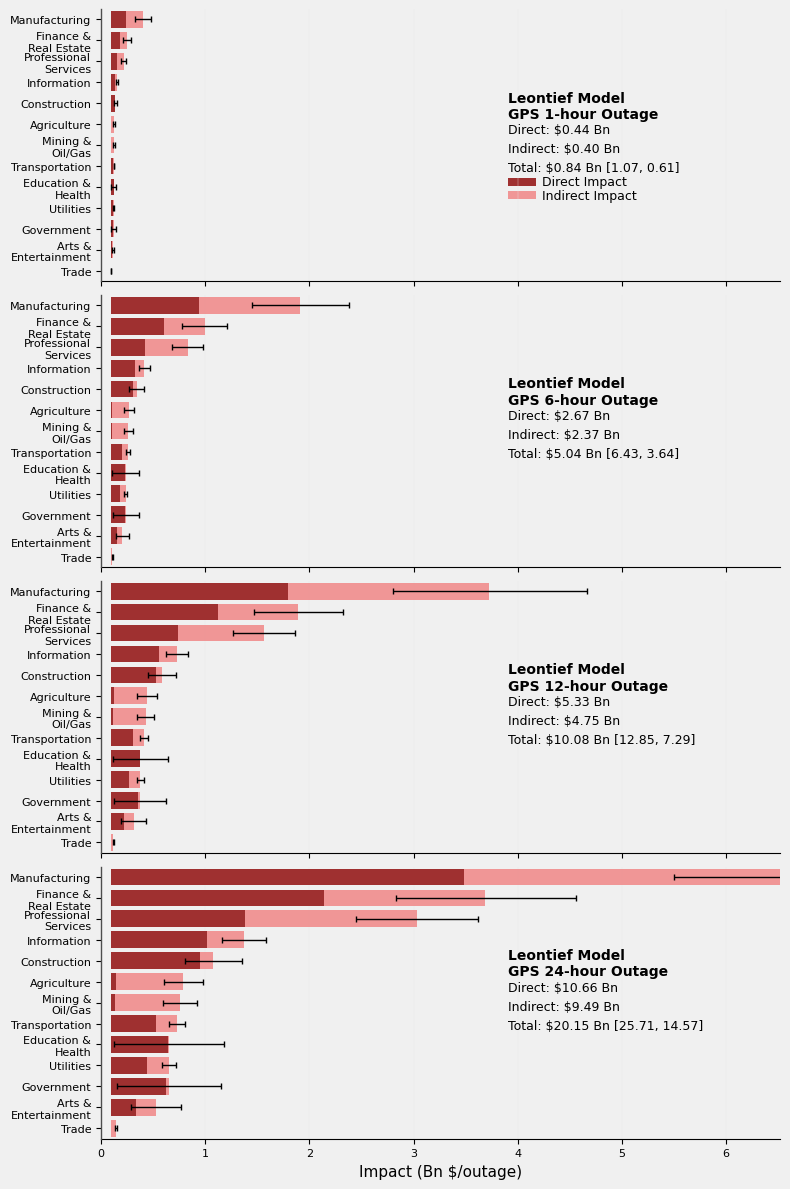

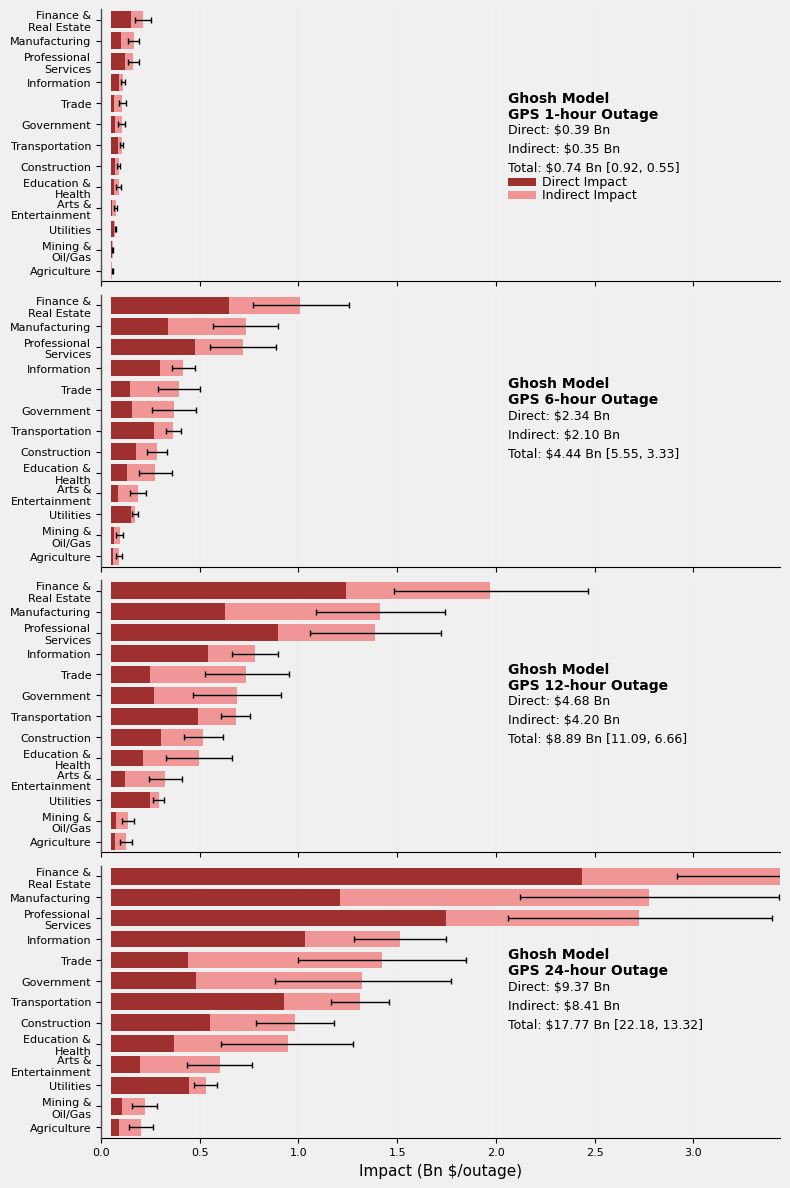

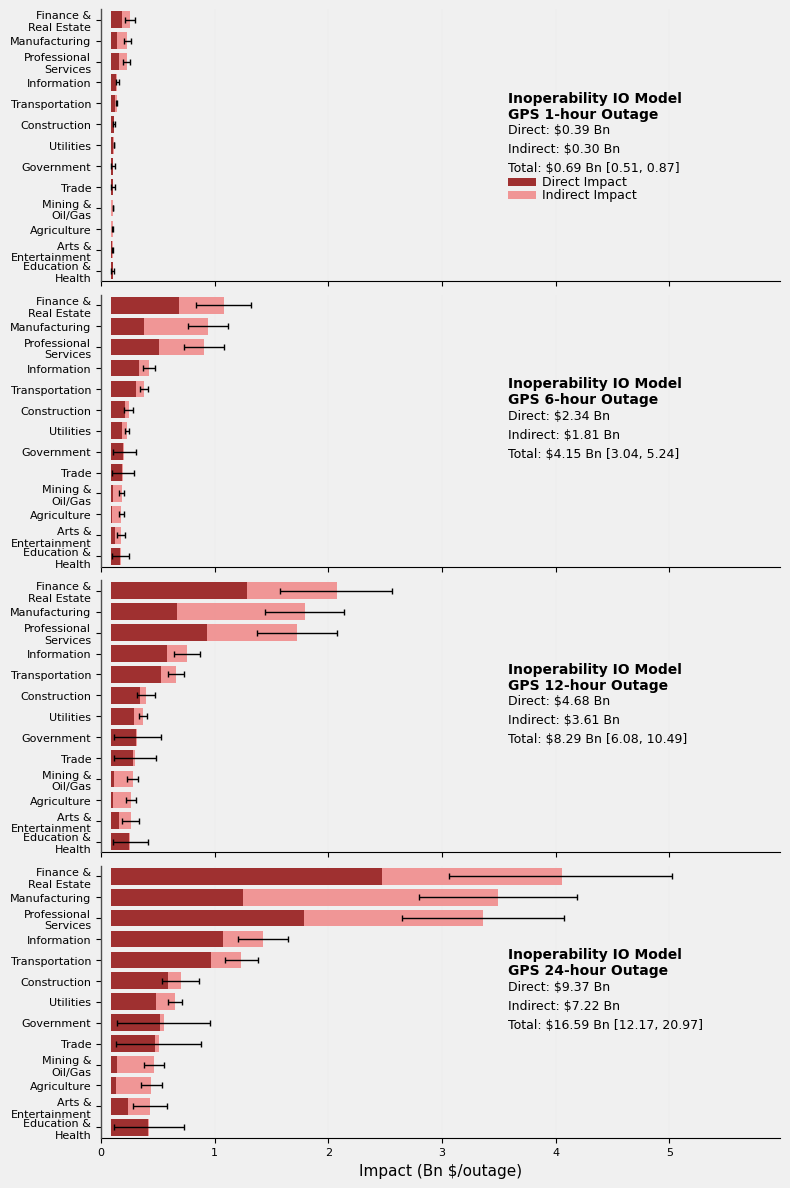

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

def plot_results(losses, model_name):
# Format data for plotting
  plot_data = []
  for sector in losses['total'].columns:
    direct_vals = losses['direct'][sector]
    indirect_vals = losses['indirect'][sector]
    total_vals = losses['total'][sector]

    plot_data.append({
        'sector': sector,
        'direct_shock': direct_vals.mean(),
        'multiplier_effect': indirect_vals.mean(),
        'total_impact': total_vals.mean(),
        'total_p025': total_vals.quantile(0.025),
        'total_p975': total_vals.quantile(0.975)
    })

  df = pd.DataFrame(plot_data).set_index('sector')

  sector_labels = {
    'AGR': 'Agriculture',
    'MINING': 'Mining &\nOil/Gas',
    'UTILITIES': 'Utilities',
    'CONSTR': 'Construction',
    'MANUF': 'Manufacturing',
    'TRADE': 'Trade',
    'TRANS': 'Transportation',
    'INFO': 'Information',
    'FIRE': 'Finance &\nReal Estate',
    'PROF_OTHER': 'Professional\nServices',
    'EDUC_HEALTH': 'Education &\nHealth',
    'ART_ENT': 'Arts &\nEntertainment',
    'G': 'Government'
}

  # Time duration scenarios and conversion factors
  durations = ['1-hour', '6-hour', '12-hour', '24-hour']
  conversion_factors = {
    '1-hour': 1/(365*24),
    '6-hour': 1/(365*4),
    '12-hour': 1/(365*2),
    '24-hour': 1/365
}

  sector_order = df.total_impact.abs().sort_values(ascending=False).index
  short_labels = [sector_labels[s] for s in sector_order]

# Calculate max_x across all scenarios for consistent scaling
  max_vals = []
  for duration in durations:
    factor = conversion_factors[duration]
    temp_high = np.abs(df.total_p975) * factor
    max_vals.append(temp_high.max())
  max_x = max(max_vals) * 1.21

  baseline_gap = max_x * 0.015

  fig, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

  for i, duration in enumerate(durations):
    ax = axes[i]
    factor = conversion_factors[duration]

    # Convert annual losses to duration-specific losses
    df_duration = df * factor
    df_ordered = df_duration.reindex(sector_order)

    direct = np.abs(df_ordered.direct_shock)
    indirect = np.abs(df_ordered.multiplier_effect)
    total_mean = np.abs(df_ordered.total_impact)
    total_low = np.abs(df_ordered.total_p025)
    total_high = np.abs(df_ordered.total_p975)

    lower_err = np.abs(total_mean - total_low)
    upper_err = np.abs(total_high - total_mean)

    y = np.arange(len(sector_order))[::-1]

    ax.barh(y, direct, left=baseline_gap, color='darkred', alpha=.8, height=.8, zorder=3)
    ax.barh(y, indirect, left=direct + baseline_gap, color='lightcoral', alpha=.8, height=.8, zorder=3)
    ax.errorbar(total_mean + baseline_gap, y, xerr=[lower_err, upper_err],
                fmt='none', color='black', capsize=2, capthick=1, elinewidth=1, zorder=4)

    ax.set_xlim(0, max_x)
    ax.set_ylim(-.5, len(sector_order)-.5)
    ax.grid(True, axis='x', linewidth=.25, color='0.9', zorder=0)
    ax.spines['left'].set_color('0.3')
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['left'].set_zorder(5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Summary statistics
    direct_mean = direct.sum()
    indirect_mean = indirect.sum()
    total_sum = total_mean.sum()
    total_low_sum = total_low.sum()
    total_high_sum = total_high.sum()

    sx, sy, dy = .6, .7, .07
    ax.text(sx, sy, f'{model_name}\nGPS {duration} Outage', transform=ax.transAxes,
            ha='left', va='top', fontsize=10, fontweight='bold')
    ax.text(sx, sy-dy-0.05, f'Direct: ${direct_mean:.2f} Bn',
            transform=ax.transAxes, ha='left', va='top', fontsize=9)
    ax.text(sx, sy-2*dy-0.05, f'Indirect: ${indirect_mean:.2f} Bn',
            transform=ax.transAxes, ha='left', va='top', fontsize=9)
    ax.text(sx, sy-3*dy-0.05, f'Total: ${total_sum:.2f} Bn [{total_low_sum:.2f}, {total_high_sum:.2f}]',
            transform=ax.transAxes, ha='left', va='top', fontsize=9)

    # Legend only on first panel
    if i == 0:
        ax.add_patch(Rectangle((sx, sy-5*dy), 0.04, 0.03,
                              facecolor='darkred', alpha=0.8, transform=ax.transAxes))
        ax.text(sx+0.05, sy-5*dy+0.015, 'Direct Impact', transform=ax.transAxes,
                ha='left', va='center', fontsize=9)
        ax.add_patch(Rectangle((sx, sy-5.7*dy), 0.04, 0.03,
                              facecolor='lightcoral', alpha=0.8, transform=ax.transAxes))
        ax.text(sx+0.05, sy-5.7*dy+0.015, 'Indirect Impact', transform=ax.transAxes,
                ha='left', va='center', fontsize=9)

    ax.set_yticks(y)
    ax.set_yticklabels(short_labels, fontsize=10)

    if i == 3:
        ax.set_xlabel('Impact (Bn $/outage)', fontsize=11)
    else:
        ax.tick_params(labelbottom=False)

    ax.tick_params(labelsize=8)
    ax.set_facecolor('#F0F0F0')

  fig.patch.set_facecolor('#F0F0F0')
  plt.tight_layout()
  plt.subplots_adjust(hspace=0.05)

  filename = model_name.replace(" ", "_") + ".png"
  fig.savefig(filename, dpi=300, bbox_inches = "tight")
  plt.show()
plot_results(losses_leontief, "Leontief Model")
plot_results(losses_g, "Ghosh Model")
plot_results(losses_iim, "Inoperability IO Model")